In [69]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [70]:
emotion_columns = [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",
    "curiosity",
    "desire",
    "disappointment",
    "disapproval",
    "disgust",
    "embarrassment",
    "excitement",
    "fear",
    "gratitude",
    "grief",
    "joy",
    "love",
    "nervousness",
    "optimism",
    "pride",
    "realization",
    "relief",
    "remorse",
    "sadness",
    "surprise",
    "neutral"
]

X_scaled = df[emotion_columns]

print(X_scaled.shape)

(61079, 28)


In [71]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Training completed.")

Training completed.


In [72]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_):.2%}")

Explained Variance Ratio:
[0.10541008 0.07325263]
Total Explained Variance: 17.87%


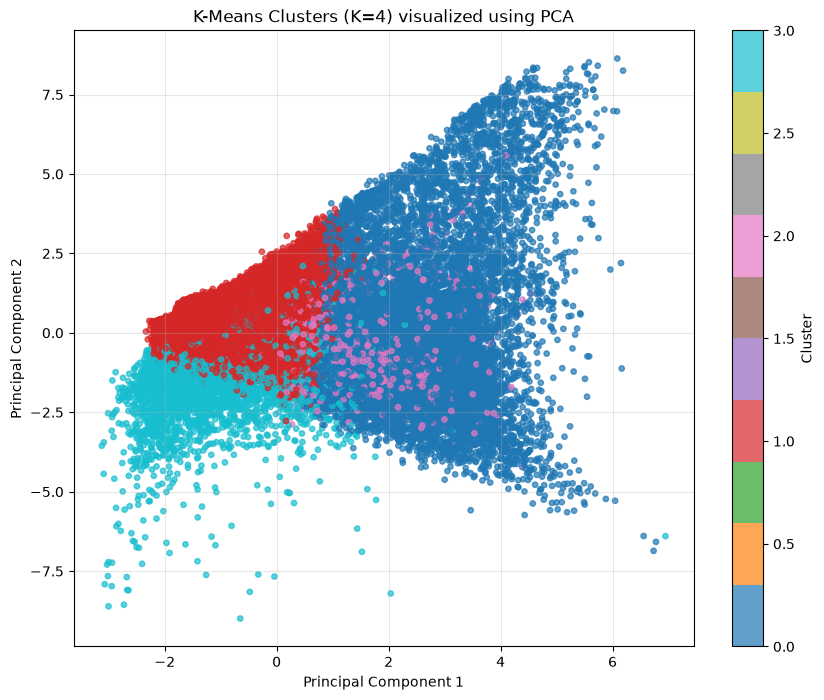

In [73]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap="tab10",
    s=15,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (K=4) visualized using PCA")

plt.colorbar(scatter, label="Cluster")

plt.grid(alpha=0.3)
plt.savefig("pca_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

c:\Users\pramo\OneDrive\Desktop\Social Media and Mental Health\mental-health-using-emotions\env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


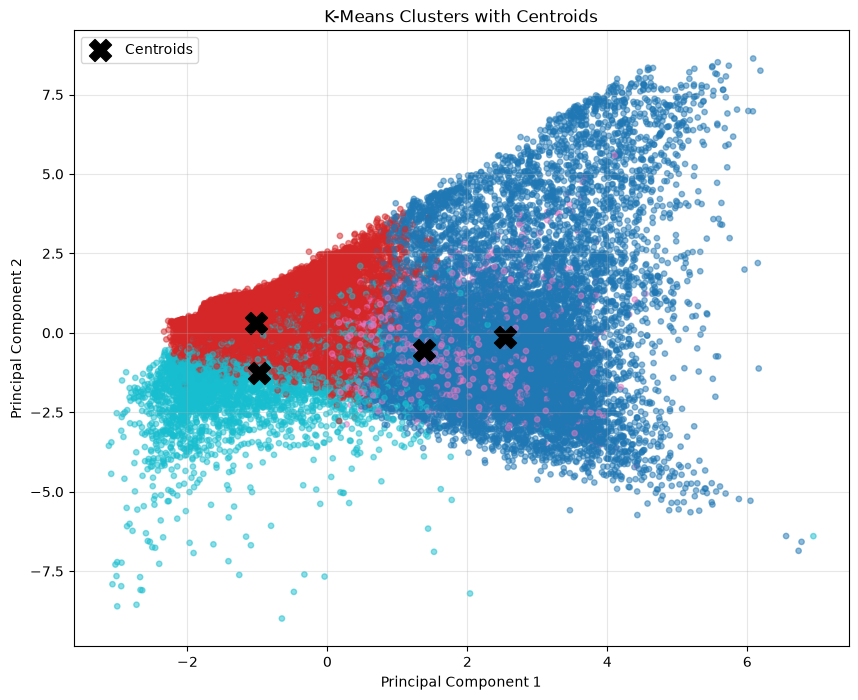

In [74]:
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap="tab10",
    s=15,
    alpha=0.5
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c="black",
    s=250,
    marker="X",
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters with Centroids")

plt.legend()

plt.grid(alpha=0.3)
plt.savefig("pca_clusters_with_centroids.png", dpi=300, bbox_inches="tight")
plt.show()

In [75]:
print("="*40)
print(f"Inertia               : {kmeans.inertia_:.2f}")
print(f"Silhouette Score      : {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"Davies-Bouldin Index  : {davies_bouldin_score(X_scaled, cluster_labels):.4f}")
print(f"Calinski-Harabasz     : {calinski_harabasz_score(X_scaled, cluster_labels):.2f}")
print("="*40)

Inertia               : 1395360.21
Silhouette Score      : 0.1919
Davies-Bouldin Index  : 2.2403
Calinski-Harabasz     : 4593.70


In [76]:
for cluster in range(kmeans.n_clusters):

    print("=" * 80)
    print(f"Cluster {cluster}")
    print("=" * 80)

    # Indices of samples in this cluster
    indices = np.where(cluster_labels == cluster)[0]

    # Samples belonging to this cluster
    cluster_points = X_scaled.iloc[indices].to_numpy()

    # Cluster centroid
    centroid = kmeans.cluster_centers_[cluster]

    # Euclidean distance from centroid
    distances = np.linalg.norm(cluster_points - centroid, axis=1)

    # 10 closest comments
    nearest_indices = indices[np.argsort(distances)[:10]]

    for idx in nearest_indices:
        print(df.iloc[idx]["comment_text"])
        print("-" * 80)

Cluster 0
i have been on anti-depressants for nearly two months. They've been working really well for me, and the effects seemed to kick in after just a couple of days. Before I spoke up and had help, I was having suicidal thoughts nearly every minute of every day for at least a few months. It was something that grew over the course of about four years - stemming from early in high school. And it began affecting my work. It would translate into stress and anger at work and I would threaten customers and punch holes in walls and destroy property. i have always had anger issues, and never had much self-esteem or confidence in my life. And as my depression got worse, my social life completely deteriorated. It wasn't something I identified as depression for a long time though. The point I guess i am trying to get across is: Ask for help. Hopefully there is someone who you can trust, and who will help you. Medication is helping me. It may help you too.
--------------------------------------

In [77]:
cluster_profile = (
    df.groupby("cluster")[emotion_columns]
    .mean()
)

cluster_profile

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.419879,-0.089540,0.498927,0.733130,-0.431418,-0.291076,-0.003699,-0.092106,0.008908,1.311772,...,-0.208187,-0.147799,-0.218597,-0.122151,-0.077054,-0.239011,0.537721,1.374805,-0.093759,-0.298987
1,0.232477,0.037948,-0.162142,-0.245368,0.193131,0.180118,-0.002859,0.044847,0.043578,-0.446427,...,0.139533,-0.287050,0.136005,-0.091188,-0.197005,-0.177942,-0.199951,-0.463341,-0.115986,0.205275
2,-0.462264,-0.073632,-0.069236,-0.077720,-0.417724,-0.319819,0.172577,0.072036,-0.181103,-0.153151,...,-0.276685,2.945956,-0.267375,-0.061972,0.108799,0.023343,-0.090639,-0.082852,-0.001435,-0.394845
3,-0.073845,0.041246,-0.157800,-0.204357,0.182594,-0.178768,-0.116032,-0.120553,-0.163304,-0.304258,...,-0.159379,-0.162997,-0.116369,0.982046,1.430147,1.796943,0.012266,-0.414474,1.023302,-0.263737


In [78]:
cluster_profile = (
    df.groupby("cluster")[emotion_columns]
    .mean()
)

print(cluster_profile)

         admiration  amusement     anger  annoyance  approval    caring  \
cluster                                                                   
0         -0.419879  -0.089540  0.498927   0.733130 -0.431418 -0.291076   
1          0.232477   0.037948 -0.162142  -0.245368  0.193131  0.180118   
2         -0.462264  -0.073632 -0.069236  -0.077720 -0.417724 -0.319819   
3         -0.073845   0.041246 -0.157800  -0.204357  0.182594 -0.178768   

         confusion  curiosity    desire  disappointment  ...      love  \
cluster                                                  ...             
0        -0.003699  -0.092106  0.008908        1.311772  ... -0.208187   
1        -0.002859   0.044847  0.043578       -0.446427  ...  0.139533   
2         0.172577   0.072036 -0.181103       -0.153151  ... -0.276685   
3        -0.116032  -0.120553 -0.163304       -0.304258  ... -0.159379   

         nervousness  optimism     pride  realization    relief   remorse  \
cluster                    

In [79]:
for cluster in cluster_profile.index:

    print("="*60)

    print(f"Cluster {cluster}")

    print("="*60)

    top = cluster_profile.loc[cluster] \
                         .sort_values(ascending=False) \
                         .head(5)

    print(top)

    print()

Cluster 0
sadness           1.374805
disappointment    1.311772
grief             1.054640
annoyance         0.733130
remorse           0.537721
Name: 0, dtype: float64

Cluster 1
gratitude     0.241197
admiration    0.232477
neutral       0.205275
approval      0.193131
caring        0.180118
Name: 1, dtype: float64

Cluster 2
fear             3.012828
nervousness      2.945956
embarrassment    0.372296
grief            0.254880
disgust          0.219113
Name: 2, dtype: float64

Cluster 3
joy            1.875117
relief         1.796943
realization    1.430147
excitement     1.198395
surprise       1.023302
Name: 3, dtype: float64



In [80]:
from sklearn.metrics import pairwise_distances

for cluster in range(4):

    print("="*80)
    print(f"Cluster {cluster}")
    print("="*80)

    indices = np.where(cluster_labels == cluster)[0]

    cluster_points = X_scaled.iloc[indices]

    centroid = kmeans.cluster_centers_[cluster]

    distances = pairwise_distances(
        cluster_points,
        centroid.reshape(1,-1)
    ).flatten()

    nearest = indices[np.argsort(distances)[:10]]

    for i in nearest:
        print(df.iloc[i]["comment_text"])
        print("-"*60)

Cluster 0
i have been on anti-depressants for nearly two months. They've been working really well for me, and the effects seemed to kick in after just a couple of days. Before I spoke up and had help, I was having suicidal thoughts nearly every minute of every day for at least a few months. It was something that grew over the course of about four years - stemming from early in high school. And it began affecting my work. It would translate into stress and anger at work and I would threaten customers and punch holes in walls and destroy property. i have always had anger issues, and never had much self-esteem or confidence in my life. And as my depression got worse, my social life completely deteriorated. It wasn't something I identified as depression for a long time though. The point I guess i am trying to get across is: Ask for help. Hopefully there is someone who you can trust, and who will help you. Medication is helping me. It may help you too.
--------------------------------------